# Prueba del Modelo de Regresión Logística

Importamos las libreria que vamos a utilizar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


Cargamos nuestro dataset.

In [2]:
f = "../data/default_credit_balanced.csv" # ruta al archivo CSV
df = pd.read_csv(f)
df.head()

,ORIGINAL_ID,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,22083,1,90000,2,1,2,28,0,0,0,2,2,2,38355,39413,41181,41701,44000,45651,1700,2404,1500,3000,2500,600,0,Femenino,Posgrado,Soltero,20-29
1,20843,2,180000,1,1,1,40,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1,Masculino,Posgrado,Casado,40-49
2,6774,3,470000,2,2,2,32,0,0,0,0,0,0,491428,488642,485382,360959,338592,123737,300000,15937,11891,120000,6380,250000,1,Femenino,Universidad,Soltero,30-39
3,17389,4,130000,2,2,2,44,2,0,0,2,2,2,72181,73086,78411,79725,81311,83048,2700,6500,3200,3500,3200,3300,1,Femenino,Universidad,Soltero,40-49
4,17378,5,210000,2,1,1,38,1,-2,-1,-1,-1,-1,0,0,517,-1,932,1066,0,517,0,933,1066,462,0,Femenino,Posgrado,Casado,30-39


Hacemos una revisión rapida de la estructura del dataset.

In [3]:
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones: (30000, 30)

Columnas:
['ORIGINAL_ID', 'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_next_month', 'SEX_LABEL', 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ORIGINAL_ID         30000 non-null  int64
 1   ID                  30000 non-null  int64
 2   LIMIT_BAL           30000 non-null  int64
 3   SEX                 30000 non-null  int64
 4   EDUCATION           30000 non-null  int64
 5   MARRIAGE            30000 non-null  int64
 6   AGE                 30000 non-null  int64
 7   PAY_0               30000 non-null  int64
 8   PAY_2               30000 non-null  int64
 9   PAY_3               30000 non-null  int64
 10  PAY_4               30000 non-null  int64
 11  PAY_5               30000 non-null  int64
 12  PAY_6               30000 non-null  int64
 13  BILL_AMT1           30000 non-null  int64
 14  BILL_AMT2           30000 non-null  int64
 15  BILL_AMT3           30000 non-null  int64
 16  BILL_AMT4           30000 non-null  int64
 17  BILL

## Separación de predictores y variable objetivo

La variable objetivo es `default_next_month`, mientras que el resto de las variables serán consideradas como predictores.

Se excluyen las columnas auxiliares de texto o etiquetas, así como el identificador `ID`.

In [5]:
cols_to_drop = ["default_next_month"]

optional_drop = ["ID", "SEX_LABEL", 'EDUCATION_LABEL', 'MARRIAGE_LABEL', 'AGE_GROUP' ]
for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)


## Distribución de la variable objetivo

Antes de entrenar el modelo, es importante revisar qué tan balanceadas están las clases.

In [6]:
target_dist = y.value_counts().sort_index().to_frame("count")
target_dist["proportion"] = y.value_counts(normalize=True).sort_index()
target_dist

,count,proportion
default_next_month,,
0,17400,0.5800
1,12600,0.4200


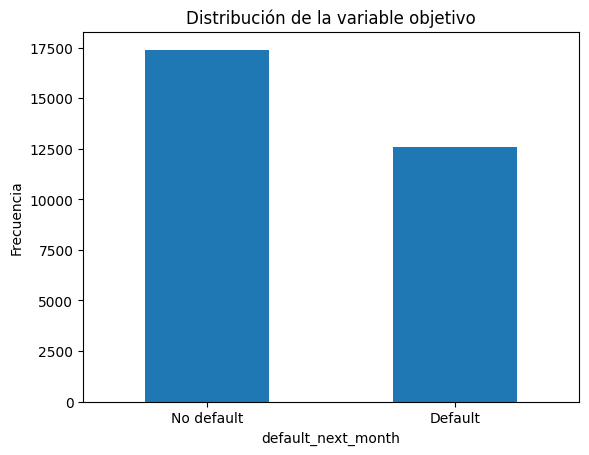

In [7]:
# Visualización de la distribución de la variable objetivo
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No default", "Default"], rotation=0)
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo")
plt.show()

## División en entrenamiento y prueba

Se divide el conjunto de datos en dos partes:

- **entrenamiento**: para ajustar el modelo,
- **prueba**: para evaluar su desempeño en datos no vistos.

Se utiliza partición estratificada para conservar aproximadamente la misma proporción de clases en ambos subconjuntos.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24000, 24)
X_test : (6000, 24)
y_train: (24000,)
y_test : (6000,)


## Identificación de variables numéricas y categóricas

Para construir el pipeline de preprocesamiento, se distinguieron las variables numéricas y categóricas.

In [9]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE']

Variables numéricas:
['ORIGINAL_ID', 'LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## Preprocesamiento

Se aplican transformaciones distintas según el tipo de variable:

- **numéricas**: imputación por mediana y escalamiento.
- **categóricas**: imputación por moda y codificación one-hot.

Este paso se integra en un pipeline para evitar fugas de información y mantener el flujo de trabajo ordenado.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Modelo baseline: regresión logística

Se construye una regresión logística como primer modelo baseline para predecir incumplimiento.

In [11]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

## Entrenamiento del modelo

In [ ]:
log_reg.fit(x_tra
            in,y_train)

NameError: name 'x_train' is not defined